We want to identify the dark and bright states associated with electromagnetic induced transparency (EIT) in our 3 level system where the field coupling the $|1\rangle\leftrightarrow|2\rangle$ transition is treated quantum mechanically.  This should be doable by looking at the eigenvalues and eigenvectors of the Hamiltonian.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg, optimize
import qutip as qu
import sympy as sym

In [2]:
# Set font size of plot elements\n",
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 18
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [3]:
# Define our symbols
ωc, Ω10, Ω21, n, Δ, δ = sym.symbols("ω_c, Ω_10, Ω_21, n, Δ, δ")

In [4]:
# Define the Hamiltonian matrix in the fixed excitation basis: {|2, n-1>, |1, n>, |0, n>}
# Note that I've defined |0, n> = (1, 0, 0)^T so the term corresponding to the atomic ground state is in the upper left corner
H = sym.Matrix([[ωc * n, Ω10, 0],
                [Ω10, ωc * n - Δ, Ω21],
                [0, Ω21, ωc * n - δ - Δ]])
H

Matrix([
[n*ω_c,      Ω_10,             0],
[ Ω_10, n*ω_c - Δ,          Ω_21],
[    0,      Ω_21, n*ω_c - Δ - δ]])

In [5]:
# Set the detunings are 0 and remove ωc. H is then
temp = H.subs([(n, 0), (Δ, 0)])
temp

Matrix([
[   0, Ω_10,    0],
[Ω_10,    0, Ω_21],
[   0, Ω_21,   -δ]])

In [6]:
# Now calculate the eigenvectors and eigenvalues
eigs = temp.eigenvects()

# Print the first
print(eigs[0][0])
eigs[0][2][0]

-δ/3 - (3*Ω_10**2 + 3*Ω_21**2 + δ**2)/(3*(-27*Ω_10**2*δ/2 + δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2)/2 + sqrt(-4*(3*Ω_10**2 + 3*Ω_21**2 + δ**2)**3 + (-27*Ω_10**2*δ + 2*δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2))**2)/2)**(1/3)) - (-27*Ω_10**2*δ/2 + δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2)/2 + sqrt(-4*(3*Ω_10**2 + 3*Ω_21**2 + δ**2)**3 + (-27*Ω_10**2*δ + 2*δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2))**2)/2)**(1/3)/3


Matrix([
[-Ω_21/Ω_10 + δ*(-δ/3 - (3*Ω_10**2 + 3*Ω_21**2 + δ**2)/(3*(-27*Ω_10**2*δ/2 + δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2)/2 + sqrt(-4*(3*Ω_10**2 + 3*Ω_21**2 + δ**2)**3 + (-27*Ω_10**2*δ + 2*δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2))**2)/2)**(1/3)) - (-27*Ω_10**2*δ/2 + δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2)/2 + sqrt(-4*(3*Ω_10**2 + 3*Ω_21**2 + δ**2)**3 + (-27*Ω_10**2*δ + 2*δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2))**2)/2)**(1/3)/3)/(Ω_10*Ω_21) + (-δ/3 - (3*Ω_10**2 + 3*Ω_21**2 + δ**2)/(3*(-27*Ω_10**2*δ/2 + δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2)/2 + sqrt(-4*(3*Ω_10**2 + 3*Ω_21**2 + δ**2)**3 + (-27*Ω_10**2*δ + 2*δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2))**2)/2)**(1/3)) - (-27*Ω_10**2*δ/2 + δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2)/2 + sqrt(-4*(3*Ω_10**2 + 3*Ω_21**2 + δ**2)**3 + (-27*Ω_10**2*δ + 2*δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2))**2)/2)**(1/3)/3)**2/(Ω_10*Ω_21)],
[                                                                                                                                                                                           

In [7]:
# Second
print(eigs[1][0])
eigs[1][2][0]

-δ/3 - (3*Ω_10**2 + 3*Ω_21**2 + δ**2)/(3*(-1/2 - sqrt(3)*I/2)*(-27*Ω_10**2*δ/2 + δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2)/2 + sqrt(-4*(3*Ω_10**2 + 3*Ω_21**2 + δ**2)**3 + (-27*Ω_10**2*δ + 2*δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2))**2)/2)**(1/3)) - (-1/2 - sqrt(3)*I/2)*(-27*Ω_10**2*δ/2 + δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2)/2 + sqrt(-4*(3*Ω_10**2 + 3*Ω_21**2 + δ**2)**3 + (-27*Ω_10**2*δ + 2*δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2))**2)/2)**(1/3)/3


Matrix([
[-Ω_21/Ω_10 + δ*(-δ/3 - (3*Ω_10**2 + 3*Ω_21**2 + δ**2)/(3*(-1/2 - sqrt(3)*I/2)*(-27*Ω_10**2*δ/2 + δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2)/2 + sqrt(-4*(3*Ω_10**2 + 3*Ω_21**2 + δ**2)**3 + (-27*Ω_10**2*δ + 2*δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2))**2)/2)**(1/3)) - (-1/2 - sqrt(3)*I/2)*(-27*Ω_10**2*δ/2 + δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2)/2 + sqrt(-4*(3*Ω_10**2 + 3*Ω_21**2 + δ**2)**3 + (-27*Ω_10**2*δ + 2*δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2))**2)/2)**(1/3)/3)/(Ω_10*Ω_21) + (-δ/3 - (3*Ω_10**2 + 3*Ω_21**2 + δ**2)/(3*(-1/2 - sqrt(3)*I/2)*(-27*Ω_10**2*δ/2 + δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2)/2 + sqrt(-4*(3*Ω_10**2 + 3*Ω_21**2 + δ**2)**3 + (-27*Ω_10**2*δ + 2*δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2))**2)/2)**(1/3)) - (-1/2 - sqrt(3)*I/2)*(-27*Ω_10**2*δ/2 + δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2)/2 + sqrt(-4*(3*Ω_10**2 + 3*Ω_21**2 + δ**2)**3 + (-27*Ω_10**2*δ + 2*δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2))**2)/2)**(1/3)/3)**2/(Ω_10*Ω_21)],
[                                                                                                       

In [8]:
# Third
print(eigs[2][0])
eigs[2][2][0]

-δ/3 - (3*Ω_10**2 + 3*Ω_21**2 + δ**2)/(3*(-1/2 + sqrt(3)*I/2)*(-27*Ω_10**2*δ/2 + δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2)/2 + sqrt(-4*(3*Ω_10**2 + 3*Ω_21**2 + δ**2)**3 + (-27*Ω_10**2*δ + 2*δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2))**2)/2)**(1/3)) - (-1/2 + sqrt(3)*I/2)*(-27*Ω_10**2*δ/2 + δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2)/2 + sqrt(-4*(3*Ω_10**2 + 3*Ω_21**2 + δ**2)**3 + (-27*Ω_10**2*δ + 2*δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2))**2)/2)**(1/3)/3


Matrix([
[-Ω_21/Ω_10 + δ*(-δ/3 - (3*Ω_10**2 + 3*Ω_21**2 + δ**2)/(3*(-1/2 + sqrt(3)*I/2)*(-27*Ω_10**2*δ/2 + δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2)/2 + sqrt(-4*(3*Ω_10**2 + 3*Ω_21**2 + δ**2)**3 + (-27*Ω_10**2*δ + 2*δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2))**2)/2)**(1/3)) - (-1/2 + sqrt(3)*I/2)*(-27*Ω_10**2*δ/2 + δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2)/2 + sqrt(-4*(3*Ω_10**2 + 3*Ω_21**2 + δ**2)**3 + (-27*Ω_10**2*δ + 2*δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2))**2)/2)**(1/3)/3)/(Ω_10*Ω_21) + (-δ/3 - (3*Ω_10**2 + 3*Ω_21**2 + δ**2)/(3*(-1/2 + sqrt(3)*I/2)*(-27*Ω_10**2*δ/2 + δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2)/2 + sqrt(-4*(3*Ω_10**2 + 3*Ω_21**2 + δ**2)**3 + (-27*Ω_10**2*δ + 2*δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2))**2)/2)**(1/3)) - (-1/2 + sqrt(3)*I/2)*(-27*Ω_10**2*δ/2 + δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2)/2 + sqrt(-4*(3*Ω_10**2 + 3*Ω_21**2 + δ**2)**3 + (-27*Ω_10**2*δ + 2*δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2))**2)/2)**(1/3)/3)**2/(Ω_10*Ω_21)],
[                                                                                                       

So the dark state is $|D\rangle = -\frac{\Omega_{21}}{\Omega_{10}}|0,n\rangle + |2, n-1\rangle$.  And the bright state is just the orthogonal superposition and is therefore $|B\rangle=\frac{\Omega_{10}}{\Omega_{21}}|0, n\rangle + |2,n-1\rangle$.  Now what happens if we let the $n\omega_c$ back into the Hamiltonian?

In [9]:
temp = H.subs([(Δ, 0), (δ, 0)])
temp

Matrix([
[n*ω_c,  Ω_10,     0],
[ Ω_10, n*ω_c,  Ω_21],
[    0,  Ω_21, n*ω_c]])

In [10]:
# Now calculate the eigenvectors and eigenvalues
eigs = temp.eigenvects()

# Print the first
print(eigs[0][0])
eigs[0][2][0]

n*ω_c


Matrix([
[-Ω_21/Ω_10],
[         0],
[         1]])

In [11]:
# Second
print(eigs[1][0])
eigs[1][2][0]

n*ω_c - sqrt(Ω_10**2 + Ω_21**2)


Matrix([
[                                           Ω_10/Ω_21],
[-n*ω_c/Ω_21 + (n*ω_c - sqrt(Ω_10**2 + Ω_21**2))/Ω_21],
[                                                   1]])

In [12]:
# Third
print(eigs[2][0])
eigs[2][2][0]

n*ω_c + sqrt(Ω_10**2 + Ω_21**2)


Matrix([
[                                           Ω_10/Ω_21],
[-n*ω_c/Ω_21 + (n*ω_c + sqrt(Ω_10**2 + Ω_21**2))/Ω_21],
[                                                   1]])

So while there is no eigenvalue of 0, that's because each eigenvalue received a constant boost of $n\omega_c$ as expected.  The eigenvalue that corresponds to 0 is just $n\omega_c$ and it turns out that the eigenvector (and therefore the dark state) doesn't change in this case.  This is also to be expected.  Adding a constant to the Hamiltonian shouldn't modify the eigenvectors.

In [13]:
p_00, p_01, p_02, p_10, p_11, p_12, p_20, p_21, p_22 = sym.symbols("p_00, p_01, p_02, p_10, p_11, p_12, p_20, p_21, p_22")
γ2, γ1, γ01, γ02, γ12, r21, r20, γ2d, γ1d = sym.symbols("γ_2, γ_1, γ_01, γ_02, γ_12, r_21, r_20, γ_2d, γ_1d")
κ, n = sym.symbols("κ, n")

In [14]:
p = sym.Matrix([[p_00, p_01, p_02],
                [p_10, p_11, p_12],
                [p_20, p_21, p_22]])
s01 = sym.Matrix([[0, 1, 0], [0, 0, 0], [0, 0, 0]])
s12 = sym.Matrix([[0, 0, 0], [0, 0, 1], [0, 0, 0]])
s11 = sym.Matrix([[0, 0, 0], [0, 1, 0], [0, 0, 0]])
s22 = sym.Matrix([[0, 0, 0], [0, 0, 0], [0, 0, 1]])

In [15]:
a = γ1 / 2 * (2 * s01 * p * s01.H - s11 * p - p * s11)
a

Matrix([
[   p_11*γ_1, -p_01*γ_1/2,           0],
[-p_10*γ_1/2,   -p_11*γ_1, -p_12*γ_1/2],
[          0, -p_21*γ_1/2,           0]])

In [16]:
b = γ2 / 2 * (2 * s12 * p * s12.H - s22 * p - p * s22)
b

Matrix([
[          0,           0, -p_02*γ_2/2],
[          0,    p_22*γ_2, -p_12*γ_2/2],
[-p_20*γ_2/2, -p_21*γ_2/2,   -p_22*γ_2]])

In [17]:
c = γ1d / 2 * (2 * s11 * p * s11.H - s11 * p - p * s11)
c

Matrix([
[           0, -p_01*γ_1d/2,            0],
[-p_10*γ_1d/2,            0, -p_12*γ_1d/2],
[           0, -p_21*γ_1d/2,            0]])

In [18]:
d = γ2d / 2 * (2 * s22 * p * s22.H - s22 * p - p * s22)
d

Matrix([
[           0,            0, -p_02*γ_2d/2],
[           0,            0, -p_12*γ_2d/2],
[-p_20*γ_2d/2, -p_21*γ_2d/2,            0]])

In [19]:
a + b + c + d

Matrix([
[                 p_11*γ_1,                            -p_01*γ_1/2 - p_01*γ_1d/2,                            -p_02*γ_2/2 - p_02*γ_2d/2],
[-p_10*γ_1/2 - p_10*γ_1d/2,                                 -p_11*γ_1 + p_22*γ_2, -p_12*γ_1/2 - p_12*γ_1d/2 - p_12*γ_2/2 - p_12*γ_2d/2],
[-p_20*γ_2/2 - p_20*γ_2d/2, -p_21*γ_1/2 - p_21*γ_1d/2 - p_21*γ_2/2 - p_21*γ_2d/2,                                            -p_22*γ_2]])

In [20]:
ann = sym.Matrix([[n, 0, 0], [0, n, 0], [0, 0, n-1]])
p_c = sym.Matrix([[p_00, p_01], [p_10, p_11]])
e = κ / 2 * (-ann * p - p * ann)
e

Matrix([
[                   -n*p_00*κ,                    -n*p_01*κ,      κ*(-n*p_02 - p_02*(n - 1))/2],
[                   -n*p_10*κ,                    -n*p_11*κ,      κ*(-n*p_12 - p_12*(n - 1))/2],
[κ*(-n*p_20 + p_20*(1 - n))/2, κ*(-n*p_21 + p_21*(1 - n))/2, κ*(p_22*(1 - n) - p_22*(n - 1))/2]])

In [21]:
p * s22 + s22 * p

Matrix([
[   0,    0,   p_02],
[   0,    0,   p_12],
[p_20, p_21, 2*p_22]])

Let's try and recreate fig 1c from the Ningyuan paper that Kevin sent over.

In [97]:
δl = np.linspace(-20, 20, 100) # detuning parameter in MHz
g21 = 5  # cavity coupling strength in MHz
g10 = 5   # probe coupling strength in MHz
κ = 1
γ21 = 0.05
γ10 = 1

In [101]:
Ts = np.zeros(δl.shape[0], dtype=complex)
for i in range(δl.shape[0]):
    Hi = np.array([[δl[i] + 1j * κ, -g10, 0],
                   [-g10, δl[i] + 1j * γ10 + 1j * κ, -g21],
                   [0, -g21, δl[i] + 1j * γ21]], dtype=complex)
    if i==0:
        print(Hi)
    Ts[i] = (κ / 2) ** 2 * np.abs(np.array([0, 0, 1]).conj().T @ np.linalg.inv(Hi) @ np.array([0, 0, 1])) ** 2
print(Ts.max())

[[-20.+1.j    -5.+0.j     0.+0.j  ]
 [ -5.+0.j   -20.+2.j    -5.+0.j  ]
 [  0.+0.j    -5.+0.j   -20.+0.05j]]
(0.22763801566957803+0j)


/home/jacob/anaconda3/envs/mode_cooling/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/jacob/anaconda3/envs/mode_cooling/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


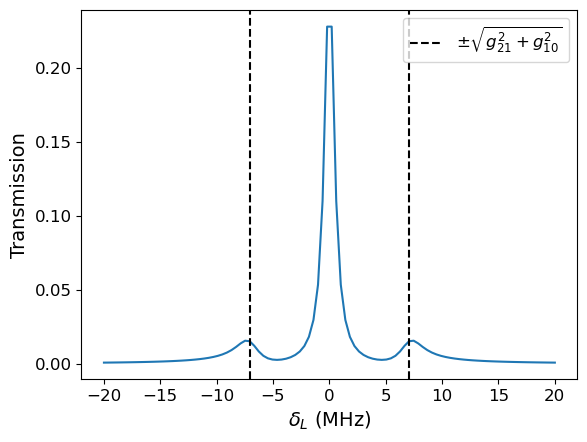

In [102]:
plt.plot(δl, Ts)
plt.xlabel("$\\delta_L$ (MHz)")
plt.ylabel("Transmission")
plt.axvline(x=-np.sqrt(g21 ** 2 + g10 ** 2), linestyle='--', color='k', label='$\\pm\\sqrt{g_{21}^2 + g_{10}^2}$')
plt.axvline(x=np.sqrt(g21 ** 2 + g10 ** 2), linestyle='--', color='k')
plt.legend()
#plt.savefig("transmission_vs_delta_L.png", format='png', dpi=300)

## 4 Level

In [25]:
# We'll redefine our symbols to make sure there's no confusion
ωc, g10, g21, g32, n, δ, Δ1, Δ2 = sym.symbols("ω_c, g_10, g_21, g_32, n, δ, Δ1, Δ2")

In [26]:
# Define the Hamiltonian
H = sym.Matrix([[n * ωc, g10, 0, 0],
                [g10, n * ωc - Δ1, g21, 0],
                [0, g21, n * ωc - Δ1 - Δ2, g32],
                [0, 0, g32, n * ωc - δ - Δ1 - Δ2]])
H

Matrix([
[n*ω_c,       g_10,               0,                   0],
[ g_10, n*ω_c - Δ1,            g_21,                   0],
[    0,       g_21, n*ω_c - Δ1 - Δ2,                g_32],
[    0,          0,            g_32, n*ω_c - Δ1 - Δ2 - δ]])

In [27]:
# Set the detunings to zero and calculate the eigenvectors and eigenvalues
temp = H.subs([(n, 0), (δ, 0), (Δ1, 0), (Δ2, 0)])
print(temp)
eigs = temp.eigenvects()

Matrix([[0, g_10, 0, 0], [g_10, 0, g_21, 0], [0, g_21, 0, g_32], [0, 0, g_32, 0]])


In [28]:
eigs[3][0]

sqrt(g_10**2/2 + g_21**2/2 + g_32**2/2 + sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_32**2 + g_32**4)/2)

In [29]:
# first eigenvalue and eigvenvector
print("First eigenvalue: ", eigs[0][0])
eigs[0][2][0]

First eigenvalue:  -sqrt(g_10**2/2 + g_21**2/2 + g_32**2/2 - sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_32**2 + g_32**4)/2)


Matrix([
[-(-g_21**2 - g_32**2)*sqrt(g_10**2/2 + g_21**2/2 + g_32**2/2 - sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_32**2 + g_32**4)/2)/(g_10*g_21*g_32) - (g_10**2/2 + g_21**2/2 + g_32**2/2 - sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_32**2 + g_32**4)/2)**(3/2)/(g_10*g_21*g_32)],
[                                                                                                                                                                                  -g_32/g_21 + (g_10**2/2 + g_21**2/2 + g_32**2/2 - sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_32**2 + g_32**4)/2)/(g_21*g_32)],
[                                                                                                                                                                                                 -sqrt(g_10**2/2 + g_21**2/2 + g_32**2/2 - sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*

In [30]:
# second
print("Second eigenvalue: ", eigs[1][0])
eigs[1][2][0]

Second eigenvalue:  sqrt(g_10**2/2 + g_21**2/2 + g_32**2/2 - sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_32**2 + g_32**4)/2)


Matrix([
[(-g_21**2 - g_32**2)*sqrt(g_10**2/2 + g_21**2/2 + g_32**2/2 - sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_32**2 + g_32**4)/2)/(g_10*g_21*g_32) + (g_10**2/2 + g_21**2/2 + g_32**2/2 - sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_32**2 + g_32**4)/2)**(3/2)/(g_10*g_21*g_32)],
[                                                                                                                                                                                 -g_32/g_21 + (g_10**2/2 + g_21**2/2 + g_32**2/2 - sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_32**2 + g_32**4)/2)/(g_21*g_32)],
[                                                                                                                                                                                                 sqrt(g_10**2/2 + g_21**2/2 + g_32**2/2 - sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_3

In [31]:
# third
print("Third eigenvalue: ", eigs[2][0])
eigs[2][2][0]

Third eigenvalue:  -sqrt(g_10**2/2 + g_21**2/2 + g_32**2/2 + sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_32**2 + g_32**4)/2)


Matrix([
[-(-g_21**2 - g_32**2)*sqrt(g_10**2/2 + g_21**2/2 + g_32**2/2 + sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_32**2 + g_32**4)/2)/(g_10*g_21*g_32) - (g_10**2/2 + g_21**2/2 + g_32**2/2 + sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_32**2 + g_32**4)/2)**(3/2)/(g_10*g_21*g_32)],
[                                                                                                                                                                                  -g_32/g_21 + (g_10**2/2 + g_21**2/2 + g_32**2/2 + sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_32**2 + g_32**4)/2)/(g_21*g_32)],
[                                                                                                                                                                                                 -sqrt(g_10**2/2 + g_21**2/2 + g_32**2/2 + sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*

In [32]:
# fourth
print("Fourth eigenvalue: ", eigs[3][0])
eigs[3][2][0]

Fourth eigenvalue:  sqrt(g_10**2/2 + g_21**2/2 + g_32**2/2 + sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_32**2 + g_32**4)/2)


Matrix([
[(-g_21**2 - g_32**2)*sqrt(g_10**2/2 + g_21**2/2 + g_32**2/2 + sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_32**2 + g_32**4)/2)/(g_10*g_21*g_32) + (g_10**2/2 + g_21**2/2 + g_32**2/2 + sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_32**2 + g_32**4)/2)**(3/2)/(g_10*g_21*g_32)],
[                                                                                                                                                                                 -g_32/g_21 + (g_10**2/2 + g_21**2/2 + g_32**2/2 + sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_32**2 + g_32**4)/2)/(g_21*g_32)],
[                                                                                                                                                                                                 sqrt(g_10**2/2 + g_21**2/2 + g_32**2/2 + sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_3

So it seems that there isn't a dark state in that none of the eigenvalues are 0 and the all of the eigenvector on all of the basis states.  I wonder if it's possible to show that that's the case from 3x3 case?

In [33]:
δl = np.linspace(-25, 25, 100) # detuning parameter in MHz
g32 = 0.1 / 2  # cavity coupling strength in MHz
g21 = 13 / 2  # probe 1 coupling strength in MHz
g10 = 7 / 2   # probe 2 coupling strength in MHz
κ = 2
γ32 = 0.1
γ21 = 0.1
γ10 = 0.1

In [34]:
λ1 = np.sqrt((g10 ** 2 + g21 ** 2 + g32 ** 2) / 2 - 0.5 * np.sqrt(g10 ** 4 + 2*g10**2*g21**2 - 2*g10**2*g32**2 + g21**4 + 2*g21**2*g32**2 + g32**4))
λ0 = -λ1
λ3 = np.sqrt((g10 ** 2 + g21 ** 2 + g32 ** 2) / 2 + 0.5 * np.sqrt(g10 ** 4 + 2*g10**2*g21**2 - 2*g10**2*g32**2 + g21**4 + 2*g21**2*g32**2 + g32**4))
λ2 = -λ3

In [35]:
Ts = np.zeros(δl.shape[0], dtype=complex)
for i in range(δl.shape[0]):
    Hi = np.array([[δl[i] + 1j * κ, g10, 0, 0],
                   [g10, δl[i] + 1j * γ10, g21, 0],
                   [0, g21, δl[i] + 1j * γ21, g32],
                   [0, 0, g32, δl[i] + 1j * γ32]], dtype=complex)
    Ts[i] = np.abs(np.array([1, 0, 0, 0]).conj().T @ np.linalg.inv(Hi) @ np.array([1, 0, 0, 0])) ** 2

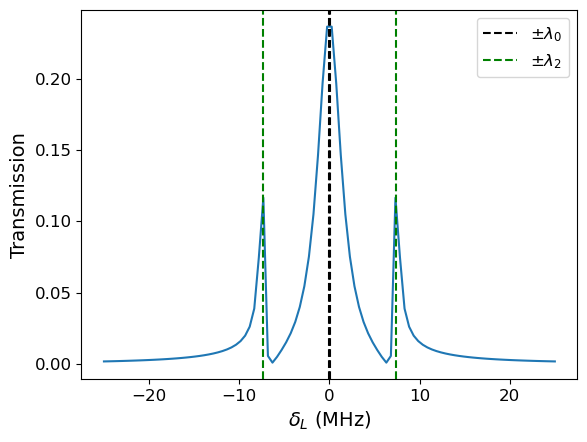

In [36]:
plt.plot(δl, Ts)
plt.xlabel("$\\delta_L$ (MHz)")
plt.ylabel("Transmission")
plt.axvline(x=λ0, linestyle='--', color='k', label='$\\pm\\lambda_0$')
plt.axvline(x=λ1, linestyle='--', color='k')
plt.axvline(x=λ2, linestyle='--', color='g', label='$\\pm\\lambda_2$')
plt.axvline(x=λ3, linestyle='--', color='g')
plt.legend()
plt.savefig("transmission_vs_delta_L_4lvl.png", format='png', dpi=300)

## 5 level
This isn't really useful, but I'm curious if the dark state will come back if we consider a 5 level system

In [37]:
g10, g21, g32, g43 = sym.symbols("g_10, g_21, g_32, g_43")

In [38]:
# Define the Hamiltonian
H = sym.Matrix([[0, g10, 0, 0, 0],
                [g10, 0, g21, 0, 0],
                [0, g21, 0, g32, 0],
                [0, 0, g32, 0, g43],
                [0, 0, 0, g43, 0]])
H

Matrix([
[   0, g_10,    0,    0,    0],
[g_10,    0, g_21,    0,    0],
[   0, g_21,    0, g_32,    0],
[   0,    0, g_32,    0, g_43],
[   0,    0,    0, g_43,    0]])

In [39]:
eigs = H.eigenvects()

In [40]:
eigs[0][0]

0

In [41]:
eigs[1][0]

-sqrt(g_10**2/2 + g_21**2/2 + g_32**2/2 + g_43**2/2 - sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 - 2*g_10**2*g_43**2 + g_21**4 + 2*g_21**2*g_32**2 - 2*g_21**2*g_43**2 + g_32**4 + 2*g_32**2*g_43**2 + g_43**4)/2)

In [42]:
eigs[2][0]

sqrt(g_10**2/2 + g_21**2/2 + g_32**2/2 + g_43**2/2 - sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 - 2*g_10**2*g_43**2 + g_21**4 + 2*g_21**2*g_32**2 - 2*g_21**2*g_43**2 + g_32**4 + 2*g_32**2*g_43**2 + g_43**4)/2)

In [43]:
eigs[3][0]

-sqrt(g_10**2/2 + g_21**2/2 + g_32**2/2 + g_43**2/2 + sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 - 2*g_10**2*g_43**2 + g_21**4 + 2*g_21**2*g_32**2 - 2*g_21**2*g_43**2 + g_32**4 + 2*g_32**2*g_43**2 + g_43**4)/2)

In [44]:
eigs[4][0]

sqrt(g_10**2/2 + g_21**2/2 + g_32**2/2 + g_43**2/2 + sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 - 2*g_10**2*g_43**2 + g_21**4 + 2*g_21**2*g_32**2 - 2*g_21**2*g_43**2 + g_32**4 + 2*g_32**2*g_43**2 + g_43**4)/2)

So there is a dark state in this case.  That's interesting.  Does it show up in the transmission spectrum if we do the same calculation?

In [45]:
δl = np.linspace(-25, 25, 100) # detuning parameter in MHz
g43 = 25 / 2
g32 = 19 / 2  # cavity coupling strength in MHz
g21 = 13 / 2  # probe 1 coupling strength in MHz
g10 = 7 / 2   # probe 2 coupling strength in MHz
κ = 2
γ43 = 0.01
γ32 = 0.01
γ21 = 0.01
γ10 = 0.01

In [46]:
Ts = np.zeros(δl.shape[0], dtype=complex)
for i in range(δl.shape[0]):
    Hi = np.array([[δl[i] + 1j * κ, g10, 0, 0, 0],
                   [g10, δl[i] + 1j * γ10, g21, 0, 0],
                   [0, g21, δl[i] + 1j * γ21, g32, 0],
                   [0, 0, g32, δl[i] + 1j * γ32, g43],
                   [0, 0, 0, g43, δl[i] + 1j * γ43]], dtype=complex)
    print(np.linalg.cond(Hi))
    Ts[i] = np.abs(np.array([1, 0, 0, 0, 0]).conj().T @ np.linalg.inv(Hi) @ np.array([1, 0, 0, 0, 0])) ** 2

4.725896759551994
4.954615658510919
5.2132511899722935
5.508083744876344
5.847283896686153
6.241681356421414
6.705942561211727
7.260434860276301
7.934294610068388
8.770715661373917
9.83659008655715
11.241344065172825
13.177134569700126
16.015254269427107
20.578302293400345
29.125146083183605
50.9126102174844
221.85674325885432
89.73162167322944
36.68066140195443
22.775921623309905
16.36704354799478
12.679666763731968
10.283921200429383
8.60233230504338
7.35705401546776
6.397942249300545
5.637750746784655
5.573110496987649
6.0965352159120645
6.756348254640014
7.611449365022107
8.762520166329349
10.393376528053716
12.877135872566214
17.095611046813087
25.670034406210956
49.06300966101741
67.21809098327311
30.898142678549917
18.251757196348255
12.744878923355099
9.78849145765665
8.111700222006355
7.4393290936049095
7.7106833029824235
8.576311830278419
9.815309474877788
11.197772505918701
12.110789561517706
12.110789561517706
11.197772505918701
9.815309474877774
8.576311830278415
7.7106833

Text(0, 0.5, 'Transmission')

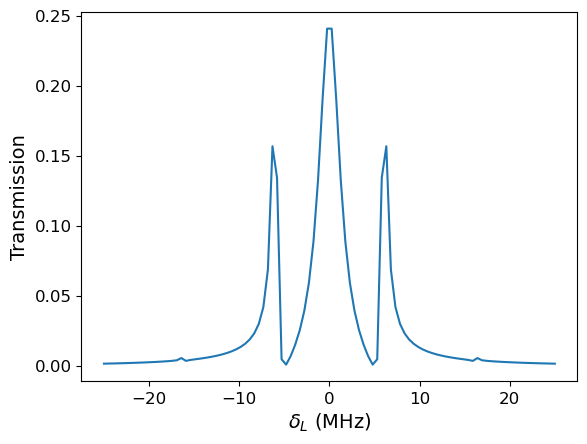

In [47]:
plt.plot(δl, Ts)
plt.xlabel("$\\delta_L$ (MHz)")
plt.ylabel("Transmission")

## Our system
We want to apply perturbation theory to a non-Hermitian Hamiltonian describing our 4 level system in order to obtain the transmission spectrum in the steady state without having to use the master equation formalism.  Our Hamiltonian is
$H_0 = -i\kappa|1,0\rangle\langle1, 0| -(\Delta_1 +i\kappa+i\gamma_1)|1, 1\rangle\langle 1, 1| -(\Delta_1+\Delta_2+i\kappa+i\gamma_2)|1, 2\rangle\langle 1, 2|-(\Delta_1+\Delta_2+\delta_c+i\gamma_3)|0, 3\rangle\langle 0, 3|+g_{32}(|0,3\rangle\langle 1, 2| +|1,2\rangle\langle0,3|) +g_{21}(|1,2\rangle\langle1,1| + |1,1\rangle\langle1, 2|) + g_{10}(|1,1\rangle\langle1, 0| + |1,0\rangle\langle1,1|)$

In [48]:
# Create symbols for Hamiltonian matrix
Δ1, Δ2, δ, κ, γ1, γ2, γ3, g32, g21, g10 = sym.symbols("Δ_1, Δ_2, δ, κ, γ_1, γ_2, γ_3, g_32, g_21, g_10")

# Create Hamiltonian
H0 = sym.Matrix([[-1j*κ, g10, 0, 0],
                [g10, -Δ1 - 1j*κ - 1j*γ1, g21, 0],
                [0, g21, -Δ1 -Δ2 -1j*κ -1j*γ2, g32],
                [0, 0, g32, -Δ1 -Δ2 -δ-1j*γ3]])
H0

Matrix([
[-1.0*I*κ,                       g_10,                                0,                          0],
[    g_10, -Δ_1 - 1.0*I*γ_1 - 1.0*I*κ,                             g_21,                          0],
[       0,                       g_21, -Δ_1 - Δ_2 - 1.0*I*γ_2 - 1.0*I*κ,                       g_32],
[       0,                          0,                             g_32, -Δ_1 - Δ_2 - 1.0*I*γ_3 - δ]])

Now from previous discussions, we want to use the dark state of the 3 level subsystem with the cavity turned off as the eigenstate will be perturb.  Initially, I considered defining this with $|1,0\rangle, |1,1\rangle, |1,2\rangle$ but the transmission spectrum seems to not have any contribution from the perturbation if you do that.  So we should probably use $|0, 0\rangle, |0,1\rangle, |0,2\rangle$ as our basis.  This also makes sense because we're ostensibly considering the cavity to be turned off.  In general, the dark state is going to depend on the detunings, the linewidth terms, and the coupling strengths in a complicated fashion, so we'll try to just evaluate that numerically.

In [49]:
# Define the sub Hamitltonian to obtain the dark state
Hd = sym.Matrix([[0, g10, 0],
                 [g10, -Δ1 -1j*γ1, g21],
                 [0, g21, -Δ1 -Δ2 -1j*γ2]])
Hd

Matrix([
[   0,             g_10,                      0],
[g_10, -Δ_1 - 1.0*I*γ_1,                   g_21],
[   0,             g_21, -Δ_1 - Δ_2 - 1.0*I*γ_2]])

In [50]:
# Now try and find which eigenstate is the dark state
# To simplify things, let's set Δ1=Δ2=0 and γ1=γ2=γ
γ = sym.symbols("γ")
temp = Hd.subs([(Δ1, 0), (Δ2, 0), (γ1, γ), (γ2, γ)])
temp

Matrix([
[   0,     g_10,        0],
[g_10, -1.0*I*γ,     g_21],
[   0,     g_21, -1.0*I*γ]])

In [51]:
# Now get eigenstates
eigs = temp.eigenvects()
eigs[0][0], eigs[0][2][0]

(-0.666666666666667*I*γ - 0.333333333333333*(3.0*g_10**2 + 3.0*g_21**2 - γ**2)/(-13.5*I*g_10**2*γ - 8.0*I*γ**3 - 9.0*I*γ*(-g_10**2 - g_21**2 - γ**2) + 0.5*(-4.0*(3.0*g_10**2 + 3.0*g_21**2 - γ**2)**3 + (-27.0*I*g_10**2*γ - 16.0*I*γ**3 - 18.0*I*γ*(-g_10**2 - g_21**2 - γ**2))**2)**0.5)**0.333333333333333 - 0.333333333333333*(-13.5*I*g_10**2*γ - 8.0*I*γ**3 - 9.0*I*γ*(-g_10**2 - g_21**2 - γ**2) + 0.5*(-4.0*(3.0*g_10**2 + 3.0*g_21**2 - γ**2)**3 + (-27.0*I*g_10**2*γ - 16.0*I*γ**3 - 18.0*I*γ*(-g_10**2 - g_21**2 - γ**2))**2)**0.5)**0.333333333333333,
 Matrix([
 [2.0*I*γ*(-0.666666666666667*I*γ - 0.333333333333333*(3.0*g_10**2 + 3.0*g_21**2 - γ**2)/(-13.5*I*g_10**2*γ - 8.0*I*γ**3 - 9.0*I*γ*(-g_10**2 - g_21**2 - γ**2) + 0.5*(-4.0*(3.0*g_10**2 + 3.0*g_21**2 - γ**2)**3 + (-27.0*I*g_10**2*γ - 16.0*I*γ**3 - 18.0*I*γ*(-g_10**2 - g_21**2 - γ**2))**2)**0.5)**0.333333333333333 - 0.333333333333333*(-13.5*I*g_10**2*γ - 8.0*I*γ**3 - 9.0*I*γ*(-g_10**2 - g_21**2 - γ**2) + 0.5*(-4.0*(3.0*g_10**2 + 3.0*g_21**2 

In [52]:
eigs[1][0],eigs[1][2][0]

(-0.666666666666667*I*γ + (0.166666666666667 - 0.288675134594813*I)*(3.0*g_10**2 + 3.0*g_21**2 - γ**2)/(-13.5*I*g_10**2*γ - 8.0*I*γ**3 - 9.0*I*γ*(-g_10**2 - g_21**2 - γ**2) + 0.5*(-4.0*(3.0*g_10**2 + 3.0*g_21**2 - γ**2)**3 + (-27.0*I*g_10**2*γ - 16.0*I*γ**3 - 18.0*I*γ*(-g_10**2 - g_21**2 - γ**2))**2)**0.5)**0.333333333333333 + (0.166666666666667 + 0.288675134594813*I)*(-13.5*I*g_10**2*γ - 8.0*I*γ**3 - 9.0*I*γ*(-g_10**2 - g_21**2 - γ**2) + 0.5*(-4.0*(3.0*g_10**2 + 3.0*g_21**2 - γ**2)**3 + (-27.0*I*g_10**2*γ - 16.0*I*γ**3 - 18.0*I*γ*(-g_10**2 - g_21**2 - γ**2))**2)**0.5)**0.333333333333333,
 Matrix([
 [2.0*I*γ*(-0.666666666666667*I*γ + (0.166666666666667 - 0.288675134594813*I)*(3.0*g_10**2 + 3.0*g_21**2 - γ**2)/(-13.5*I*g_10**2*γ - 8.0*I*γ**3 - 9.0*I*γ*(-g_10**2 - g_21**2 - γ**2) + 0.5*(-4.0*(3.0*g_10**2 + 3.0*g_21**2 - γ**2)**3 + (-27.0*I*g_10**2*γ - 16.0*I*γ**3 - 18.0*I*γ*(-g_10**2 - g_21**2 - γ**2))**2)**0.5)**0.333333333333333 + (0.166666666666667 + 0.288675134594813*I)*(-13.5*I*g_10

In [53]:
eigs[2][0],eigs[2][2][0]

(-0.666666666666667*I*γ + (0.166666666666667 + 0.288675134594813*I)*(3.0*g_10**2 + 3.0*g_21**2 - γ**2)/(-13.5*I*g_10**2*γ - 8.0*I*γ**3 - 9.0*I*γ*(-g_10**2 - g_21**2 - γ**2) + 0.5*(-4.0*(3.0*g_10**2 + 3.0*g_21**2 - γ**2)**3 + (-27.0*I*g_10**2*γ - 16.0*I*γ**3 - 18.0*I*γ*(-g_10**2 - g_21**2 - γ**2))**2)**0.5)**0.333333333333333 + (0.166666666666667 - 0.288675134594813*I)*(-13.5*I*g_10**2*γ - 8.0*I*γ**3 - 9.0*I*γ*(-g_10**2 - g_21**2 - γ**2) + 0.5*(-4.0*(3.0*g_10**2 + 3.0*g_21**2 - γ**2)**3 + (-27.0*I*g_10**2*γ - 16.0*I*γ**3 - 18.0*I*γ*(-g_10**2 - g_21**2 - γ**2))**2)**0.5)**0.333333333333333,
 Matrix([
 [2.0*I*γ*(-0.666666666666667*I*γ + (0.166666666666667 + 0.288675134594813*I)*(3.0*g_10**2 + 3.0*g_21**2 - γ**2)/(-13.5*I*g_10**2*γ - 8.0*I*γ**3 - 9.0*I*γ*(-g_10**2 - g_21**2 - γ**2) + 0.5*(-4.0*(3.0*g_10**2 + 3.0*g_21**2 - γ**2)**3 + (-27.0*I*g_10**2*γ - 16.0*I*γ**3 - 18.0*I*γ*(-g_10**2 - g_21**2 - γ**2))**2)**0.5)**0.333333333333333 + (0.166666666666667 - 0.288675134594813*I)*(-13.5*I*g_10

It'll be easier for now to proceed using numbers instead of trying to fiddle with obtaining an analytic result.  Also worth pointing out that it might be possible to get a nicer expression if we solve this by hand instead of relying on sympy.

In [54]:
# Define our parameters numerically
g32 = 50
g21 = 10
g10 = 50
κ = 1
γ1 = 1
γ2 = 0.05

In [55]:
λ1 = np.sqrt((g10 ** 2 + g21 ** 2 + g32 ** 2) / 2 - 0.5 * np.sqrt(g10 ** 4 + 2*g10**2*g21**2 - 2*g10**2*g32**2 + g21**4 + 2*g21**2*g32**2 + g32**4))
λ0 = -λ1
λ3 = np.sqrt((g10 ** 2 + g21 ** 2 + g32 ** 2) / 2 + 0.5 * np.sqrt(g10 ** 4 + 2*g10**2*g21**2 - 2*g10**2*g32**2 + g21**4 + 2*g21**2*g32**2 + g32**4))
λ2 = -λ3

In [56]:
print(λ0, λ1, λ2, λ3)

-45.24937810560445 45.24937810560445 -55.24937810560445 55.24937810560445


In [57]:
# Define the Hamiltonian and get the eigenstates
Hd = np.array([[0, g10, 0],
               [g10, 0, g21],
               [0, g21, 0]])
Hd

array([[ 0, 50,  0],
       [50,  0, 10],
       [ 0, 10,  0]])

In [58]:
# Get eigenstuff
num_eigs = linalg.eigh(Hd)
num_eigs

(array([-5.09901951e+01,  7.81597009e-14,  5.09901951e+01]),
 array([[ 6.93375245e-01, -1.96116135e-01,  6.93375245e-01],
        [-7.07106781e-01, -2.50828011e-16,  7.07106781e-01],
        [ 1.38675049e-01,  9.80580676e-01,  1.38675049e-01]]))

In [59]:
num_eigs[1].T

array([[ 6.93375245e-01, -7.07106781e-01,  1.38675049e-01],
       [-1.96116135e-01, -2.50828011e-16,  9.80580676e-01],
       [ 6.93375245e-01,  7.07106781e-01,  1.38675049e-01]])

In [60]:
Hd @ num_eigs[1].T[2]

array([35.35533906, 36.05551275,  7.07106781])

In [61]:
num_eigs[0][2] * num_eigs[1].T[2]

array([35.35533906, 36.05551275,  7.07106781])

In [62]:
# What if we include the non-hermitian terms in Hd?
nonH_Hd = np.array([[0, g10, 0],
               [g10, -1j*γ1, g21],
               [0, g21, -1j*γ2]])
nonH_Hd

array([[ 0.+0.j  , 50.+0.j  ,  0.+0.j  ],
       [50.+0.j  , -0.-1.j  , 10.+0.j  ],
       [ 0.+0.j  , 10.+0.j  , -0.-0.05j]])

In [63]:
num_eigs = linalg.eig(nonH_Hd)
num_eigs

(array([ 5.09877521e+01-0.50096156j, -5.09877521e+01-0.50096156j,
        -1.32569496e-16-0.04807689j]),
 array([[ 6.93341537e-01+6.81217430e-03j, -6.93341537e-01+6.81217430e-03j,
         -1.96119584e-01+1.38777878e-17j],
        [ 7.07106781e-01+0.00000000e+00j,  7.07106781e-01+0.00000000e+00j,
          2.71050543e-18+1.88576390e-04j],
        [ 1.38670846e-01+1.22647533e-03j, -1.38670846e-01+1.22647533e-03j,
          9.80579968e-01+0.00000000e+00j]]))

Now we want to evaluate the transmission spectrum.  Earlier, we were having issues with the full four level calculation giving highly asymmetric results for the transmission spectrum.  We'll start with a bad approximation for debugging purposes where we assume that the $|0,3\rangle$ state just doesn't exist.

In [64]:
# Let's sweep over δ
δl = np.linspace(-25, 25, 100) #+ num_eigs[0][2]
c_Ts = np.zeros(δl.shape[0])
ψd_Ts = np.zeros(δl.shape[0])
c = np.array([1/np.sqrt(3), 1/np.sqrt(3), 1/np.sqrt(3)])
ψd = np.array([num_eigs[1].T[1][0], num_eigs[1].T[1][1], num_eigs[1].T[1][2]])
for i in range(δl.shape[0]):
    hi = np.array([[-1j*κ, g10, 0],
                   [g10, -1j*γ1-1j*κ, g21],
                   [0, g21, -1j*γ2-1j*κ]], dtype=complex)
    temp = (δl[i] + num_eigs[0][1]) * np.eye(3) - hi
    #print(np.linalg.cond(temp))
    inv = np.linalg.inv(temp)
    c_Ts[i] = (κ/2) ** 2 * np.abs(c.conj().T @ inv @ ψd) ** 2
    ψd_Ts[i] = (κ/2) ** 2 * np.abs(ψd.conj().T @ inv @ ψd) ** 2

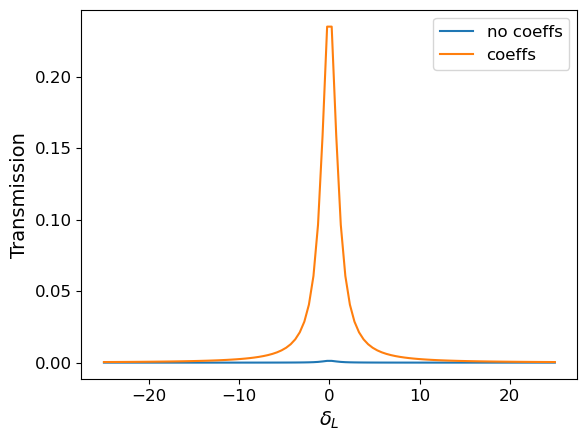

In [65]:
plt.plot(δl, c_Ts, label='no coeffs')
plt.plot(δl, ψd_Ts, label='coeffs')
plt.xlabel("$\\delta_L$")
plt.ylabel("Transmission")
plt.legend()

After playing around with the calculation a bit, I realized that the asymmetry seemed to be caused by the definition of $|C\rangle$ we were using.  Initially, I assumed that $|C\rangle=\frac{1}{\sqrt{3}}(|1,0\rangle + |1,1\rangle + |1,2\rangle)$.  The thing that seemed to correct it was using $|C\rangle=c_0|1,0\rangle + c_1|1,1\rangle + c_2|1,2\rangle$, where the coefficients come from the dark state.  My thinking is that the asymmetry arose because we were effectively considering different population distributions of the atomic energy levels, so the overlap ended up kind of skewed.  This also seems to apply to the full four level case.

In [66]:
# Let's sweep over δ
δl = np.linspace(-25, 25, 100)
c_Ts = np.zeros(δl.shape[0])
ψd_Ts = np.zeros(δl.shape[0])
c = np.array([1/np.sqrt(3), 1/np.sqrt(3), 1/np.sqrt(3), 0])
ψd = np.array([num_eigs[1].T[1][0], num_eigs[1].T[1][1], num_eigs[1].T[1][2], 0])
for i in range(δl.shape[0]):
    hi = np.array([[-1j*κ, g10, 0, 0],
                   [g10, -1j*γ1-1j*κ, g21, 0],
                   [0, g21, -1j*γ2-1j*κ, g32],
                   [0, 0, g32, -1j*γ2]], dtype=complex)
    #print(np.linalg.cond(hi))
    temp = (δl[i] + num_eigs[0][1]) * np.eye(4) - hi
    inv = np.linalg.inv(temp)
    c_Ts[i] = (κ/2) ** 2 * np.abs(c.conj().T @ inv @ ψd) ** 2
    ψd_Ts[i] = (κ/2) ** 2 * np.abs(ψd.conj().T @ inv @ ψd) ** 2

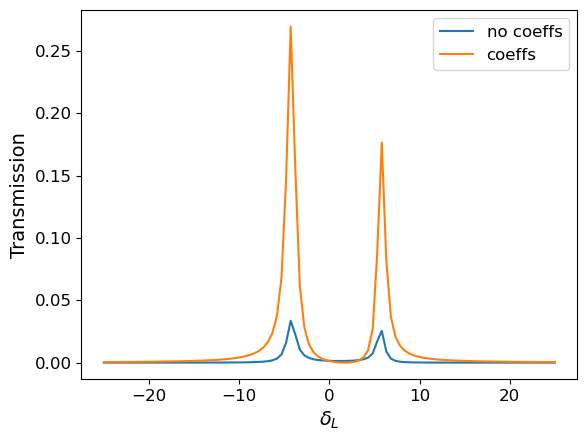

In [67]:
plt.plot(δl, c_Ts, label='no coeffs')
plt.plot(δl, ψd_Ts, label='coeffs')
plt.xlabel("$\\delta_L$")
plt.ylabel("Transmission")
plt.legend()
#plt.savefig("pert_theory_test.png", format='png', dpi=300)

So in the full 4 level case, it seems that we get the vacuum Rabi splitting of the cavity.  Kevin suggested that the separation between the peaks should scale linearly with $g_{32}$.

In [68]:
# Set up vector and parameter arrays
g32_vals = np.array([1, 3, 5, 7])
#g32_vals = np.linspace(1, 20, 100)
δl = np.linspace(-25, 25, 1000)
ψd = np.array([num_eigs[1].T[1][0], num_eigs[1].T[1][1], num_eigs[1].T[1][2], 0])

# Set up array for storing transmission spectra and loop
Ts = np.zeros((g32_vals.shape[0], δl.shape[0]))
λs = np.zeros(g32_vals.shape[0])
for i in range(g32_vals.shape[0]):
    λs[i] = np.sqrt((g10 ** 2 + g21 ** 2 + g32_vals[i] ** 2) / 2 - 0.5 * np.sqrt(g10 ** 4 + 2*g10**2*g21**2 - 2*g10**2*g32_vals[i]**2 + g21**4 + 2*g21**2*g32_vals[i]**2 + g32_vals[i]**4))
    for j in range(δl.shape[0]):
        hi = np.array([[-1j*κ, g10, 0, 0],
                       [g10, -1j*γ1-1j*κ, g21, 0],
                       [0, g21, -1j*γ2-1j*κ, g32_vals[i]],
                       [0, 0, g32_vals[i], -1j*γ2]], dtype=complex)
        #print(np.linalg.cond(hi))
        temp = (δl[j] + num_eigs[0][1]) * np.eye(4) - hi
        inv = np.linalg.inv(temp)
    
        Ts[i][j] = (κ/2) ** 2 * np.abs(ψd.conj().T @ inv @ ψd) ** 2

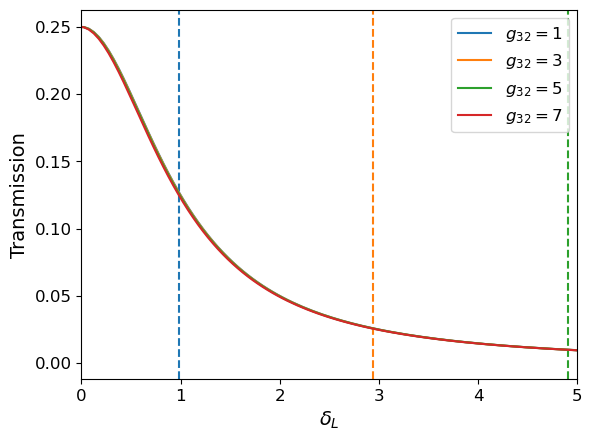

In [69]:
colors=['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
for i in range(g32_vals.shape[0]):
    plt.plot(δl, Ts[i], color=colors[i], label='$g_{32}='+str(g32_vals[i])+'$')
    plt.axvline(x=λs[i], color=colors[i], linestyle='--')
plt.xlabel("$\\delta_L$")
plt.ylabel("Transmission")
plt.xlim([0,5])
plt.legend()
#plt.savefig("g32_sweep_with_eigs.png", format='png', dpi=300)

Let's try and get a plot of the difference between the peaks vs the values of $g_32$.

In [70]:
# Set up array for g32 values
g32_vals = np.linspace(1, 20, 100)

# Set up left and right δL arrays
δl_left = np.linspace(-25, 0, 500)
δl_right = np.linspace(0, 25, 500)

# Now we want to calculate the transmission spectrum for each half for each value of g32
left_Ts = np.zeros((g32_vals.shape[0], δl_left.shape[0]))
right_Ts = np.zeros((g32_vals.shape[0], δl_right.shape[0]))
λs = np.zeros(g32_vals.shape[0])
for i in range(g32_vals.shape[0]):
    λs[i] = np.sqrt((g10 ** 2 + g21 ** 2 + g32_vals[i] ** 2) / 2 - 0.5 * np.sqrt(g10 ** 4 + 2*g10**2*g21**2 - 2*g10**2*g32_vals[i]**2 + g21**4 + 2*g21**2*g32_vals[i]**2 + g32_vals[i]**4))
    for j in range(δl_left.shape[0]):
        hi = np.array([[-1j*κ, g10, 0, 0],
                       [g10, -1j*γ1-1j*κ, g21, 0],
                       [0, g21, -1j*γ2-1j*κ, g32_vals[i]],
                       [0, 0, g32_vals[i], -1j*γ2]], dtype=complex)
        temp_left = (δl_left[j] + num_eigs[0][1]) * np.eye(4) - hi
        inv_left = np.linalg.inv(temp_left)
        left_Ts[i][j] = (κ/2) ** 2 * np.abs(ψd.conj().T @ inv_left @ ψd) ** 2
        
        temp_right = (δl_right[j] + num_eigs[0][1]) * np.eye(4) - hi
        inv_right = np.linalg.inv(temp_right)
        right_Ts[i][j] = (κ/2) ** 2 * np.abs(ψd.conj().T @ inv_right @ ψd) ** 2
        

In [71]:
# Now find the location of the maximum value in each half of the transmission spectra
peak_sep = np.zeros(g32_vals.shape[0])
for i in range(g32_vals.shape[0]):
    # Get index of max value in left and right spectra
    left_ind = np.argmax(left_Ts[i])
    right_ind = np.argmax(right_Ts[i])

    # Grab the corresponding delta values and save their difference
    left_δ = δl_left[left_ind]
    right_δ = δl_right[right_ind]
    peak_sep[i] = right_δ - left_δ
    #print(left_δ, right_δ, peak_sep[i])

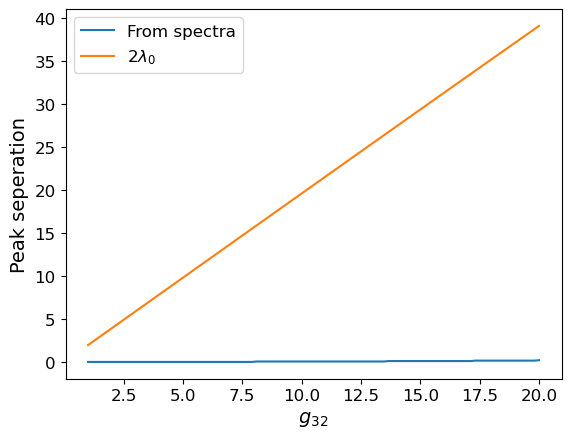

In [72]:
# plot peak separation vs g32 value
plt.plot(g32_vals, peak_sep, label='From spectra')
plt.plot(g32_vals, 2*λs, label='$2\\lambda_0$')
plt.xlabel("$g_{32}$")
plt.ylabel("Peak seperation")
plt.legend()
#plt.savefig("peak_sep_vs_g32_with_eigs.png", dpi=300, format='png')

What happens if we look at the bright states?  The update to perturbation theory that is more explicit about how the detuning $\delta_L$ shows up should mean that we get basically the same thing, I think.

In [73]:
eig_ind = 0
# Let's sweep over δ
δl = np.linspace(-100, 100, 1000)
ψb1_Ts = np.zeros(δl.shape[0])
ψb1 = np.array([num_eigs[1].T[eig_ind][0], num_eigs[1].T[eig_ind][1], num_eigs[1].T[eig_ind][2], 0])
hi = np.array([[-1j*κ, g10, 0, 0],
                   [g10, -1j*γ1-1j*κ, g21, 0],
                   [0, g21, -1j*γ2-1j*κ, g32],
                   [0, 0, g32, -1j*γ2]], dtype=complex)
eigs4 = linalg.eig(hi)
for i in range(δl.shape[0]):
    #print(np.linalg.cond(hi))
    temp = (δl[i] + num_eigs[0][eig_ind]) * np.eye(4) - hi
    inv = np.linalg.inv(temp)
    ψb1_Ts[i] = (κ/2) ** 2 * np.abs(ψb1.conj().T @ inv @ ψb1) ** 2

In [74]:
eigs4

(array([ 55.2245079 -1.07497807j,  45.26927736-0.97502193j,
        -55.2245079 -1.07497807j, -45.26927736-0.97502193j]),
 array([[ 0.4747921 +0.00064462j, -0.52203338-0.0442888j ,
         -0.4747921 +0.00064462j,  0.52203338-0.0442888j ],
        [ 0.52440416+0.j        , -0.47261935-0.04035923j,
          0.52440416+0.j        , -0.47261935+0.04035923j],
        [ 0.52203571+0.04528542j,  0.47478998-0.00970175j,
         -0.52203571+0.04528542j, -0.47478998-0.00970175j],
        [ 0.47172509+0.04975651j,  0.52440641+0.j        ,
          0.47172509-0.04975651j,  0.52440641+0.j        ]]))

In [75]:
num_eigs

(array([ 5.09877521e+01-0.50096156j, -5.09877521e+01-0.50096156j,
        -1.32569496e-16-0.04807689j]),
 array([[ 6.93341537e-01+6.81217430e-03j, -6.93341537e-01+6.81217430e-03j,
         -1.96119584e-01+1.38777878e-17j],
        [ 7.07106781e-01+0.00000000e+00j,  7.07106781e-01+0.00000000e+00j,
          2.71050543e-18+1.88576390e-04j],
        [ 1.38670846e-01+1.22647533e-03j, -1.38670846e-01+1.22647533e-03j,
          9.80579968e-01+0.00000000e+00j]]))

In [76]:
eig_ind = 1
ψd_Ts = np.zeros(δl.shape[0])
ψd = np.array([num_eigs[1].T[eig_ind][0], num_eigs[1].T[eig_ind][1], num_eigs[1].T[eig_ind][2], 0])
for i in range(δl.shape[0]):
    hi = np.array([[-1j*κ, g10, 0, 0],
                   [g10, -1j*γ1-1j*κ, g21, 0],
                   [0, g21, -1j*γ2-1j*κ, g32],
                   [0, 0, g32, 0-1j*γ2]], dtype=complex)
    #print(np.linalg.cond(hi))
    temp = (δl[i] + num_eigs[0][eig_ind]) * np.eye(4) - hi
    inv = np.linalg.inv(temp)
    ψd_Ts[i] = (κ/2) ** 2 * np.abs(ψd.conj().T @ inv @ ψd) ** 2

In [77]:
eig_ind = 2
ψb2_Ts = np.zeros(δl.shape[0])
ψb2 = np.array([num_eigs[1].T[eig_ind][0], num_eigs[1].T[eig_ind][1], num_eigs[1].T[eig_ind][2], 0])
print(ψb2)
for i in range(δl.shape[0]):
    hi = np.array([[-1j*κ, g10, 0, 0],
                   [g10, -1j*γ1-1j*κ, g21, 0],
                   [0, g21, -1j*γ2-1j*κ, g32],
                   [0, 0, g32, -1j*γ2]], dtype=complex)
    #print(np.linalg.cond(hi))
    temp = (δl[i] + num_eigs[0][eig_ind]) * np.eye(4) - hi
    inv = np.linalg.inv(temp)
    ψb2_Ts[i] = (κ/2) ** 2 * np.abs(ψb2.conj().T @ inv @ ψb2) ** 2

[-1.96119584e-01+1.38777878e-17j  2.71050543e-18+1.88576390e-04j
  9.80579968e-01+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]


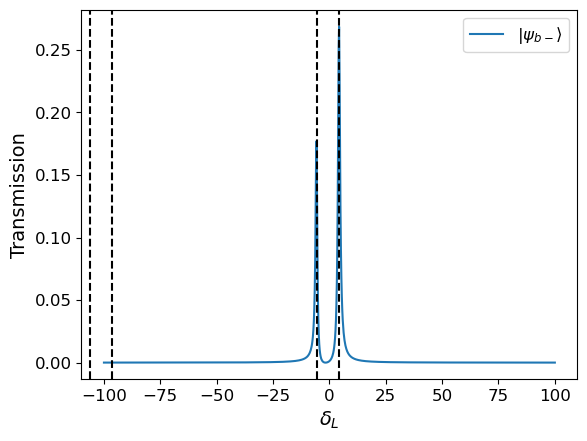

In [78]:
plt.plot(δl, ψb1_Ts, label='$|\\psi_{b-}\\rangle$')
#plt.plot(δl, ψd_Ts, label='$|\\psi_d\\rangle$')
#plt.plot(δl, ψb2_Ts, label='$|\\psi_{b+}\\rangle$')
plt.xlabel("$\\delta_L$")
plt.axvline(x=eigs4[0][0] - num_eigs[0][0], color='k', linestyle='--')
plt.axvline(x=eigs4[0][1] - num_eigs[0][0], color='k', linestyle='--')
plt.axvline(x=eigs4[0][2] - num_eigs[0][0], color='k', linestyle='--')
plt.axvline(x=eigs4[0][3] - num_eigs[0][0], color='k', linestyle='--')
plt.ylabel("Transmission")
plt.legend()

In [79]:
num_eigs[0][1]

np.complex128(-50.987752138857964-0.5009615553869482j)

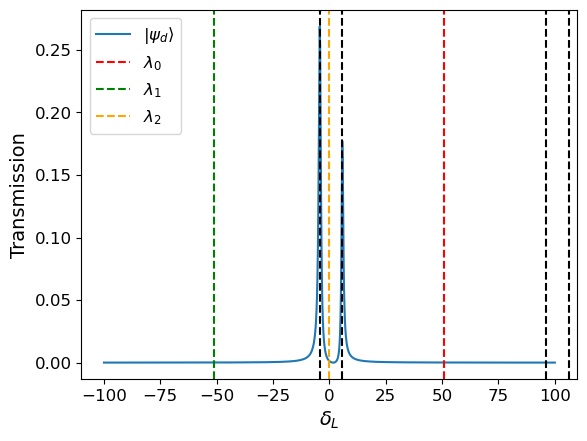

In [80]:
#plt.plot(δl, ψb1_Ts, label='$|\\psi_{b-}\\rangle$')
plt.plot(δl, ψd_Ts, label='$|\\psi_d\\rangle$')
#plt.plot(δl, ψb2_Ts, label='$|\\psi_{b+}\\rangle$')
plt.xlabel("$\\delta_L$")
plt.axvline(x=eigs4[0][0] - num_eigs[0][1], color='k', linestyle='--')
plt.axvline(x=eigs4[0][1] - num_eigs[0][1], color='k', linestyle='--')
plt.axvline(x=eigs4[0][2] - num_eigs[0][1], color='k', linestyle='--')
plt.axvline(x=eigs4[0][3] - num_eigs[0][1], color='k', linestyle='--')
plt.axvline(x=num_eigs[0][0], color='red', linestyle='--', label='$\\lambda_0$')
plt.axvline(x=num_eigs[0][1], color='green', linestyle='--', label='$\\lambda_1$')
plt.axvline(x=num_eigs[0][2], color='orange', linestyle='--', label='$\\lambda_2$')
plt.ylabel("Transmission")
plt.legend()
#plt.savefig("dark_state_spec.png", format='png', dpi=300)

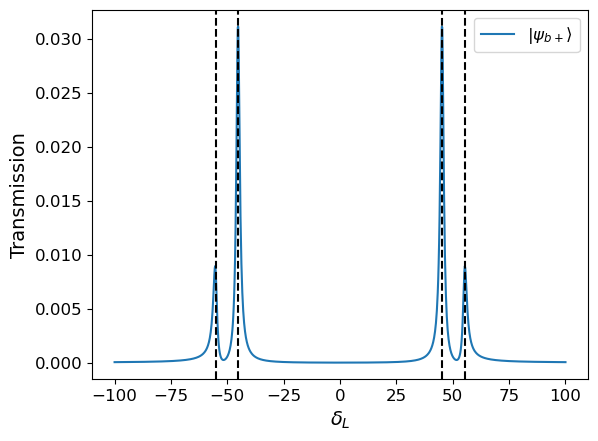

In [81]:
#plt.plot(δl, ψb1_Ts, label='$|\\psi_{b-}\\rangle$')
#plt.plot(δl, ψd_Ts, label='$|\\psi_d\\rangle$')
plt.plot(δl, ψb2_Ts, label='$|\\psi_{b+}\\rangle$')
plt.xlabel("$\\delta_L$")
plt.axvline(x=eigs4[0][0] - num_eigs[0][2], color='k', linestyle='--')
plt.axvline(x=eigs4[0][1] - num_eigs[0][2], color='k', linestyle='--')
plt.axvline(x=eigs4[0][2] - num_eigs[0][2], color='k', linestyle='--')
plt.axvline(x=eigs4[0][3] - num_eigs[0][2], color='k', linestyle='--')
plt.ylabel("Transmission")
plt.legend()

Let's try looking at this when we don't include the fourth level as a sort of sanity check.

In [82]:
eig_ind = 0
# Let's sweep over δ
δl = np.linspace(-25, 25, 100)
ψb1_Ts = np.zeros(δl.shape[0])
ψb1 = np.array([num_eigs[1].T[eig_ind][0], num_eigs[1].T[eig_ind][1], num_eigs[1].T[eig_ind][2]])
for i in range(δl.shape[0]):
    hi = np.array([[-1j*κ, g10, 0],
                   [g10, -1j*γ1-1j*κ, g21],
                   [0, g21, -1j*γ2-1j*κ]], dtype=complex)
    temp = (δl[i] + num_eigs[0][eig_ind]) * np.eye(3) - hi
    #print(np.linalg.cond(temp))
    inv = np.linalg.inv(temp)
    ψb1_Ts[i] = (κ/2) ** 2 * np.abs(ψb1.conj().T @ inv @ ψb1) ** 2

In [83]:
eig_ind = 1
# Let's sweep over δ
δl = np.linspace(-25, 25, 100)
ψd_Ts = np.zeros(δl.shape[0])
ψd = np.array([num_eigs[1].T[eig_ind][0], num_eigs[1].T[eig_ind][1], num_eigs[1].T[eig_ind][2]])
for i in range(δl.shape[0]):
    hi = np.array([[-1j*κ, g10, 0],
                   [g10, -1j*γ1-1j*κ, g21],
                   [0, g21, -1j*γ2-1j*κ]], dtype=complex)
    temp = (δl[i] + num_eigs[0][eig_ind]) * np.eye(3) - hi
    #print(np.linalg.cond(temp))
    inv = np.linalg.inv(temp)
    ψd_Ts[i] = (κ/2) ** 2 * np.abs(ψd.conj().T @ inv @ ψd) ** 2

In [84]:
eig_ind = 2
# Let's sweep over δ
δl = np.linspace(-25, 25, 100)
ψb2_Ts = np.zeros(δl.shape[0])
ψb2 = np.array([num_eigs[1].T[eig_ind][0], num_eigs[1].T[eig_ind][1], num_eigs[1].T[eig_ind][2]])
for i in range(δl.shape[0]):
    hi = np.array([[-1j*κ, g10, 0],
                   [g10, -1j*γ1-1j*κ, g21],
                   [0, g21, -1j*γ2-1j*κ]], dtype=complex)
    temp = (δl[i] + num_eigs[0][eig_ind]) * np.eye(3) - hi
    #print(np.linalg.cond(temp))
    inv = np.linalg.inv(temp)
    ψb2_Ts[i] = (κ/2) ** 2 * np.abs(ψb2.conj().T @ inv @ ψb2) ** 2

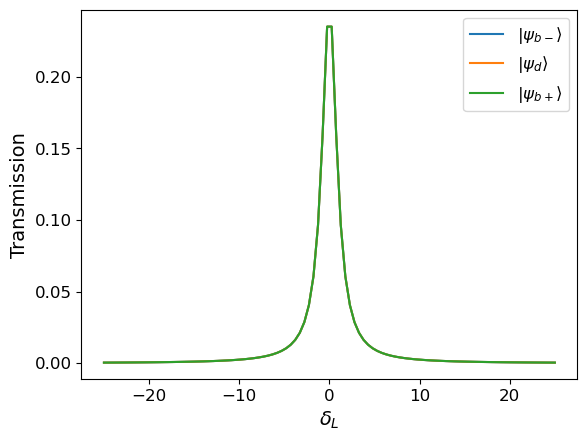

In [85]:
plt.plot(δl, ψb1_Ts, label='$|\\psi_{b-}\\rangle$')
plt.plot(δl, ψd_Ts, label='$|\\psi_d\\rangle$')
plt.plot(δl, ψb2_Ts, label='$|\\psi_{b+}\\rangle$')
plt.xlabel("$\\delta_L$")
plt.ylabel("Transmission")
plt.legend()

## Extra
Kevin suggested that it would be useful to have a waterfall plot of the transmission spectrum as $\delta_c$ and $\delta_L$ are varied.

In [86]:
# Define our δc and δL values
δc = np.linspace(-100, 100, 100)
δl = np.linspace(-100, 100, 1000)

In [87]:
# We'll look at the dark state for now
eig_ind = 2

# Define dark state vector
ψd = np.array([num_eigs[1].T[eig_ind][0], num_eigs[1].T[eig_ind][1], num_eigs[1].T[eig_ind][2], 0])

# Define array for storing transmission values
ψd_Ts = np.zeros((δc.shape[0], δl.shape[0]))

# Calculate the transmission values
for i in range(δc.shape[0]):
    hi = np.array([[-1j*κ, g10, 0, 0],
                   [g10, -1j*γ1-1j*κ, g21, 0],
                   [0, g21, -1j*γ2-1j*κ, g32],
                   [0, 0, g32, -δc[i]-1j*γ2]], dtype=complex)
    for j in range(δl.shape[0]):
        temp = (δl[j] + num_eigs[0][eig_ind]) * np.eye(4) - hi
        inv = np.linalg.inv(temp)
        ψd_Ts[i][j] = (κ / 2) ** 2 * np.abs(ψd.conj().T @ inv @ ψd) ** 2

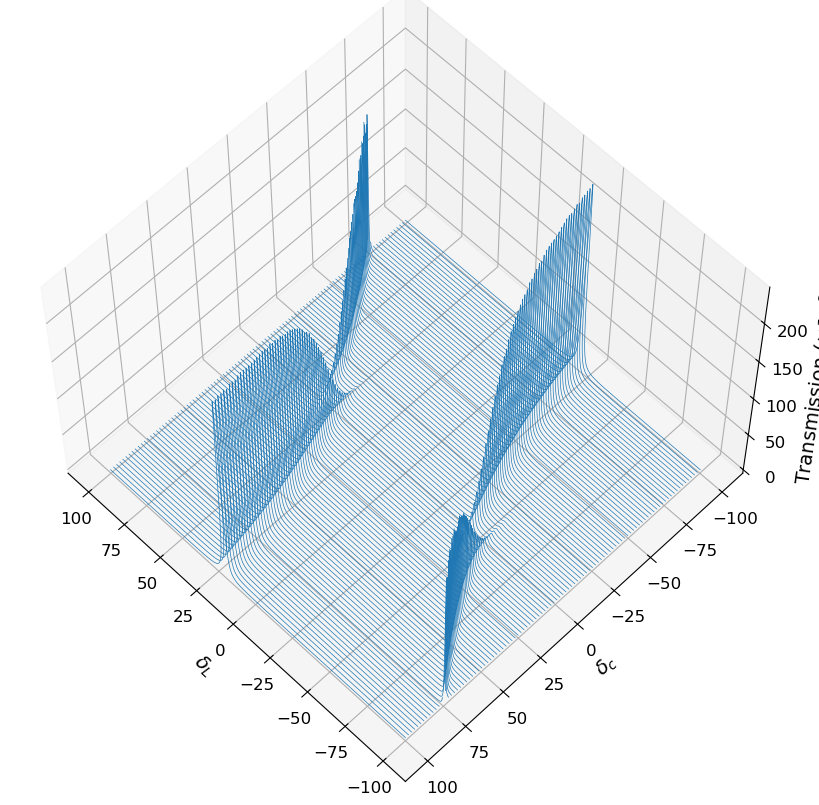

In [88]:
fig = plt.figure(1, figsize=(10,10))
ax = fig.add_subplot(projection='3d')
for i in range(δc.shape[0]):
    ax.plot(δl, δc[i]*np.ones(δl.shape), ψd_Ts[i]*1000, linewidth=0.5, color='tab:blue')
ax.set_xlabel("$\\delta_L$")
ax.set_ylabel("$\\delta_c$")
ax.set_zlabel("Transmission ($\\times 10^3$)")
ax.view_init(elev=60, azim=135, roll=0)
#plt.savefig("darkstate_waterfall_plot_g10=20_g21=10_g32=15_gamma1=1_gamma2=0,05_kappa=1.png", format='png', dpi=300)